(24, 14)
['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']
count       5.000000
mean      456.400000
std       385.505901
min       142.000000
25%       190.000000
50%       360.000000
75%       490.000000
max      1100.000000
Name: dan_so, dtype: float64


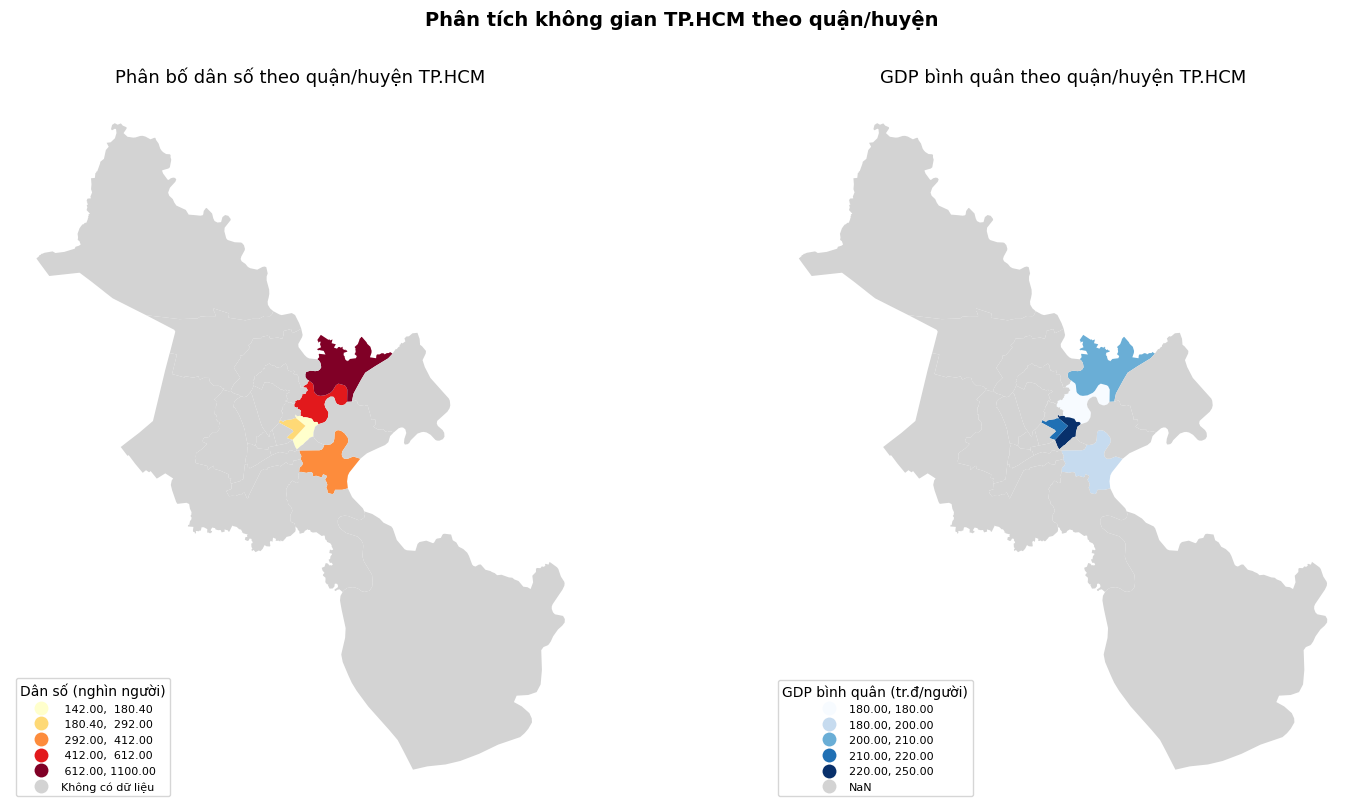

=== Thống kê dân số ===
            count    mean  std     min     25%     50%     75%     max
NAME_2                                                                
Bình Chánh    0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Bình Thạnh    1.0   490.0  NaN   490.0   490.0   490.0   490.0   490.0
Bình Tân      0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Cần Giờ       0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Củ Chi        0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Gò Vấp        0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Hóc Môn       0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Nhà Bè        0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Phú Nhuận     0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Quận 1        1.0   142.0  NaN   142.0   142.0   142.0   142.0   142.0
Quận 10       0.0     NaN  NaN     NaN     NaN     NaN     NaN     NaN
Quận 11       0.0     NaN  NaN     NaN     NaN     Na

In [33]:
#23.4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

gdf = gpd.read_file(
    "zip+https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_VNM_shp.zip!gadm41_VNM_2.shp"
)

gdf_hcm = gdf[gdf["NAME_1"] == "Hồ Chí Minh"]

print(gdf_hcm.shape)
print(gdf_hcm.columns.tolist())
gdf_hcm.head(3)

# Dữ liệu mẫu
data = {
    "NAME_2": ["Quận 1", "Quận 3", "Quận 7", "Bình Thạnh", "Thủ Đức"],
    "dan_so": [142, 190, 360, 490, 1100],  # nghìn người
    "gdp_binh_quan": [250, 220, 200, 180, 210]  # triệu đồng/người
}

df_kt = pd.DataFrame(data)

gdf_merged = gdf_hcm.merge(df_kt, on="NAME_2", how="left")

print(gdf_merged["dan_so"].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#Dân số
gdf_merged.plot(
    column="dan_so",
    ax=axes[0],
    legend=True,
    cmap="YlOrRd",
    missing_kwds={"color": "lightgrey", "label": "Không có dữ liệu"},
    scheme="quantiles",
    k=5,
    legend_kwds={"title": "Dân số (nghìn người)", "loc": "lower left", "fontsize": 8})

axes[0].set_title("Phân bố dân số theo quận/huyện TP.HCM", fontsize=13)
axes[0].axis("off")

#GDP bình quân
gdf_merged.plot(
    column="gdp_binh_quan",
    ax=axes[1],
    legend=True,
    cmap="Blues",
    missing_kwds={"color": "lightgrey"},
    scheme="fisher_jenks",
    k=5,
    legend_kwds={"title": "GDP bình quân (tr.đ/người)", "loc": "lower left", "fontsize": 8})

axes[1].set_title("GDP bình quân theo quận/huyện TP.HCM", fontsize=13)
axes[1].axis("off")

plt.suptitle("Phân tích không gian TP.HCM theo quận/huyện",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("choropleth_hcm.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Thống kê dân số ===")
print(gdf_merged.groupby("NAME_2")["dan_so"].describe())

top5 = gdf_merged.nlargest(5, "dan_so")[["NAME_2", "dan_so"]]
print("\nTop 5 quận/huyện đông dân nhất:")
print(top5.to_string(index=False))

gdf_nonan = gdf_merged.dropna(subset=["dan_so", "gdp_binh_quan"])
corr = gdf_nonan["dan_so"].corr(gdf_nonan["gdp_binh_quan"])
print(f"\nHệ số tương quan (Pearson): {corr:.3f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')